<a href="https://colab.research.google.com/github/anushabershilla/Data-science-ML/blob/main/Mall_customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


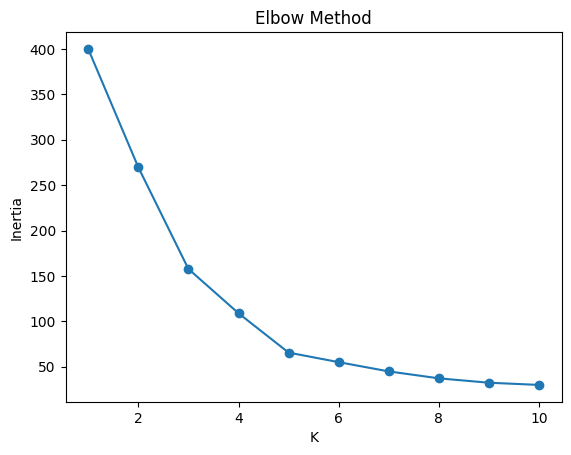

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
cluster [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


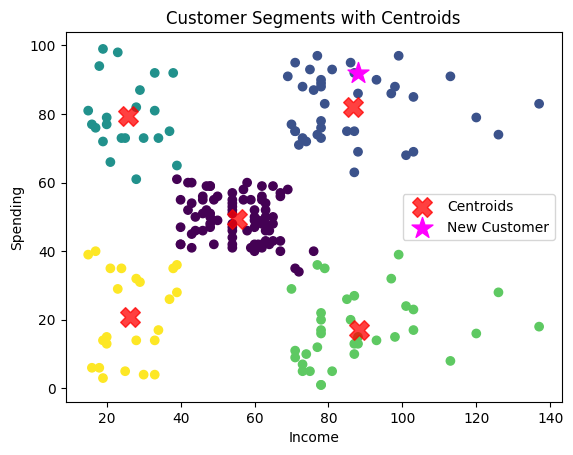

In [ ]:
#import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset

df = pd.read_csv("Mall_Customers.csv")

print(df.head())
x = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scalar
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
inertia = []

# Find best K
for k in range(1,11):

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    model.fit(x_scaled)

    inertia.append(model.inertia_)
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("K")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()
#Train model
model = KMeans(n_clusters=5, random_state=42, n_init=10)

model.fit(x_scaled)

# centers
df["Cluster"] = model.labels_
centers_scaled = model.cluster_centers_
print(centers_scaled)

# Inverse transform the scaled centers back to the original scale
centers_unscaled = scaler.inverse_transform(centers_scaled)

print(df.head())

new_customer = [[88,92]]

new_scaled = scaler.transform(new_customer)

cluster = model.predict(new_scaled)

print("cluster",cluster)


plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

# Plot the centroids on the scatter plot
plt.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    c='red', s=200, alpha=0.75, marker='X', label='Centroids'
)

# Plot the new customer point
plt.scatter(
    new_customer[0][0],
    new_customer[0][1],
    c='magenta', s=250, alpha=1, marker='*', label='New Customer'
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Customer Segments with Centroids")
plt.legend()
plt.show()